#### Life cycle of Project

- 1) Understanding the Problem Statement
- 2) Data Collection
- 3) Data Checks to perform
- 4) Exploratory data analysis
- 5) Data Pre-Processing
- 6) Feature selection
- 7) Model Training
- 8) Choose best model

### 1) Problem Statement: 

<div dir="rtl">

با استفاده از داده‌های رفتاری مشتریان، یک مدل یادگیری ماشین بسازیم که تشخیص دهد کدام مشتری دست به انجام یک تراکنش خاص می‌زند (صرف‌نظر از مبلغ آن تراکنش) .
این مسئله در دسته‌ی مسائل  (Binary Classification) قرار می‌گیرد، جایی که باید به ازای هر مشتری، یکی از دو حالت "انجام خواهد داد" (۱) یا "انجام نخواهد داد" (۰) را پیش‌بینی کنیم.

<div>

 ### 2) Data Collection
Data Source : https://www.kaggle.com/c/santander-customer-transaction-prediction

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)



from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
import optuna



In [20]:
df = pd.read_csv("santander-customer-transaction-prediction/train.csv")
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [21]:
df.shape

(200000, 202)

#### 2.2 Dataset information 
In this project, a dataset of 200,000 products with 200 features (anonymized and numerical) is provided.

### 3)Data Checks to perform

#### 3.1 Check mising values

In [4]:
df.isnull().sum().sum()

np.int64(0)

#### 3.2 Check Duplicated

In [5]:
df.duplicated().sum()

np.int64(0)

#### 3.3 Check Datatypes

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [6]:
df.dtypes.value_counts()

float64    200
object       1
int64        1
Name: count, dtype: int64

### 3.4 Checking the number of unique values of each column

In [29]:
df.nunique()

ID_code    200000
target          2
var_0       94672
var_1      108932
var_2       86555
            ...  
var_195     57870
var_196    125560
var_197     40537
var_198     94153
var_199    149430
Length: 202, dtype: int64

### 3.5 Check statistics of data set

In [30]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


#### Preparing X and Y variables

In [ ]:
target_col = "target"
y = df[target_col]
X = df.drop(columns=[target_col, "ID_code"])

In [34]:
y.value_counts().sort_values()


target
1     20098
0    179902
Name: count, dtype: int64

### 4. Exploring Data ( Visualization )


### 4.1 Univarite 

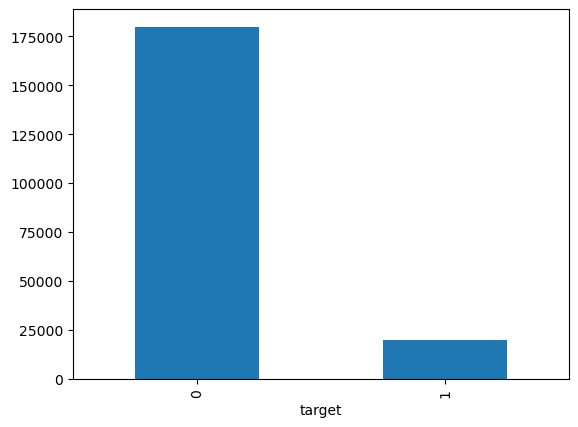

In [47]:
y.value_counts().plot(kind="bar")

plt.show()

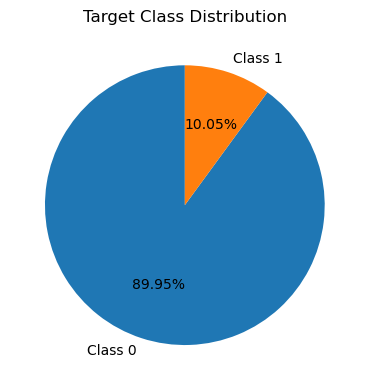

In [51]:
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(4, 4))

plt.pie(
    class_counts.values,
    labels=[f"Class {i}" for i in class_counts.index],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

### insight 
imabalance class

#### Bivariate Analyze

Feature <-> target

Pearson correlation

<div dir="rtl">
این نمودار به ما می‌گوید کدام    Featureها رابطه خطی بیشتری با Target دارند
<div>

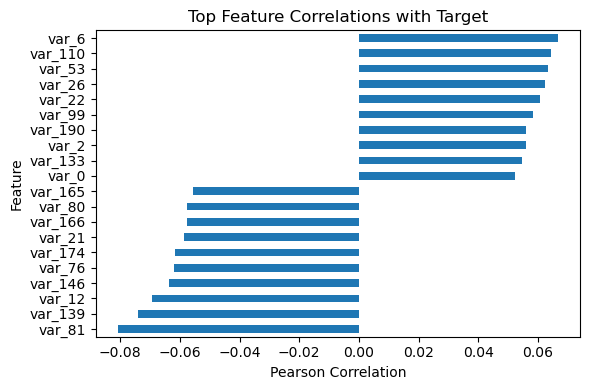

In [59]:


corr_target = X.corrwith(y).sort_values()

top_negative = corr_target.head(10)
top_positive = corr_target.tail(10)

corr_top = pd.concat([top_negative, top_positive])

plt.figure(figsize=(6, 4))

corr_top.sort_values().plot(kind="barh")

plt.title("Top Feature Correlations with Target")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

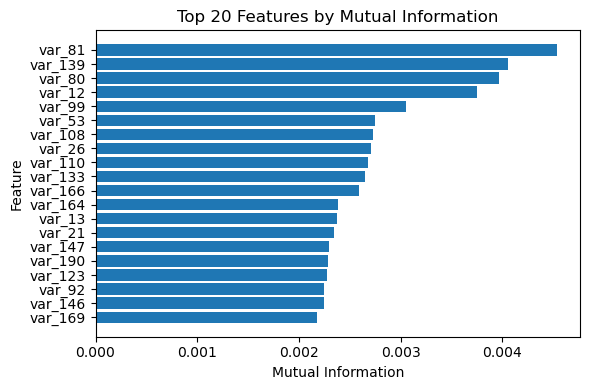

In [63]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({"feature": X.columns, "MI": mi})

mi_df = mi_df.sort_values("MI", ascending=False)

top_mi = mi_df.head(20).sort_values("MI")

plt.figure(figsize=(6, 4))
plt.barh(top_mi["feature"], top_mi["MI"])

plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [64]:
corr_target = X.corrwith(y)
corr_df = pd.DataFrame({
    "feature": corr_target.index,
    "correlation": corr_target.values
})

corr_df["abs_corr"] = corr_df["correlation"].abs()


top_corr = (corr_df.sort_values("abs_corr", ascending=False).head(20)["feature"])

common_features = set(top_corr) & set(top_mi)

print("Common features:")
print(common_features)

Common features:
set()


<div dir="rtl">
نتایج نشان داد که هیچ Feature مشترکی در 20 ویژگی برتر دو روش وجود ندارد؛ بنابراین احتمال وجود روابط غیرخطی بین برخی Featureها و Target وجود دارد.

در نتیجه، برای Feature Selection نباید فقط به Correlation تکیه کرد و بهتر است MI نیز در مراحل بعدی در نظر گرفته شود.
<div>

In [67]:
comparison = pd.DataFrame({
    "Correlation": X.corrwith(y),
    "Abs_Correlation": X.corrwith(y).abs(),
    "MI": mi
})

comparison = comparison.sort_values(
    "MI",
    ascending=False
)

print(comparison.head(10))

         Correlation  Abs_Correlation        MI
var_81     -0.080917         0.080917  0.004537
var_139    -0.074080         0.074080  0.004055
var_80     -0.057609         0.057609  0.003971
var_12     -0.069489         0.069489  0.003752
var_99      0.058367         0.058367  0.003051
var_53      0.063399         0.063399  0.002750
var_108    -0.044791         0.044791  0.002730
var_26      0.062422         0.062422  0.002711
var_110     0.064275         0.064275  0.002681
var_133     0.054548         0.054548  0.002651


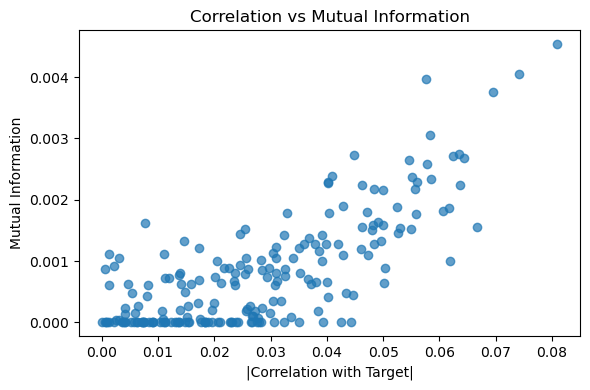

In [66]:
plt.figure(figsize=(6, 4))

plt.scatter(
    comparison["Abs_Correlation"],
    comparison["MI"],
    alpha=0.7
)

plt.xlabel("|Correlation with Target|")
plt.ylabel("Mutual Information")
plt.title("Correlation vs Mutual Information")

plt.tight_layout()
plt.show()

<div dir="rtl">
به‌منظور بررسی میزان ارتباط متغیرهای عددی با متغیر هدف، از دو معیار Pearson Correlation و Mutual Information (MI) استفاده شد. هدف از این تحلیل، شناسایی ویژگی‌هایی بود که می‌توانند اطلاعات مناسبی برای تفکیک دو کلاس Target فراهم کنند.

در تحلیل Correlation، میزان رابطه خطی بین هر Feature و Target اندازه‌گیری شد؛ در حالی که Mutual Information قادر است علاوه بر روابط خطی، وابستگی‌های غیرخطی بین Feature و Target را نیز شناسایی کند.

در نمودار، محور افقی مقدار قدرمطلق Correlation و محور عمودی مقدار Mutual Information را نشان می‌دهد. هر نقطه نمایانگر یک Feature است.



نتیجه‌گیری

بر اساس این تحلیل، استفاده همزمان از Correlation و Mutual Information برای مرحله EDA مناسب‌تر است. Correlation برای شناسایی روابط خطی و MI برای شناسایی وابستگی‌های غیرخطی مورد استفاده قرار می‌گیرد.

با این حال، در این مرحله هیچ Featureای صرفاً بر اساس این نمودار حذف نمی‌شود. ویژگی‌های مهم در مراحل بعدی با استفاده از روش‌هایی مانند SelectKBest، Feature Importance و Permutation Importance و در نهایت با ارزیابی عملکرد مدل بررسی خواهند شد.

بنابراین این نمودار بیشتر یک ابزار اکتشافی برای شناخت ساختار داده و انتخاب کاندیدهای Feature Engineering است، نه معیار نهایی حذف Featureها.
<div>

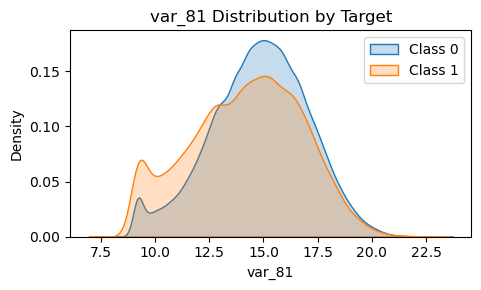

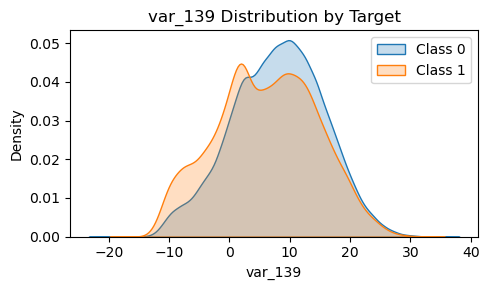

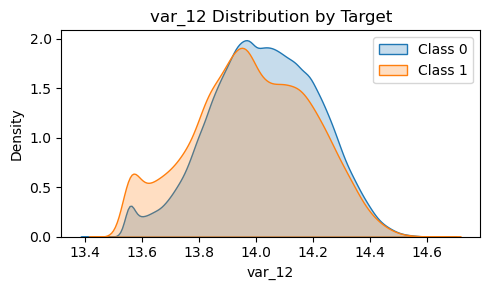

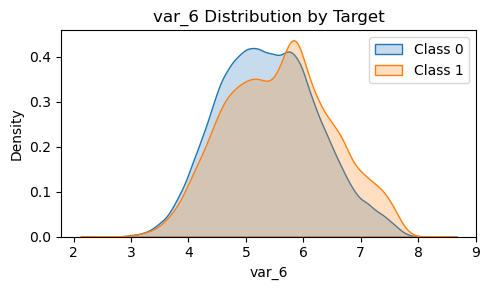

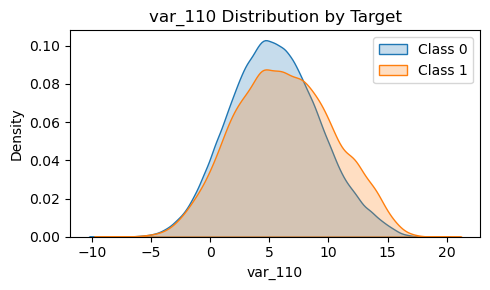

In [ ]:
top_5_corr = (corr_target.abs().sort_values(ascending=False).head(5).index)
for col in top_5_corr :

    plt.figure(figsize=(5, 3))

    sns.kdeplot(data=X.loc[y == 0], x=col, label="Class 0", fill=True)

    sns.kdeplot(data=X.loc[y == 1], x=col, label="Class 1", fill=True)

    plt.title(f"{col} Distribution by Target")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.legend()
    plt.tight_layout()
    plt.show()

Top 5 MI features:
['var_81', 'var_139', 'var_80', 'var_12', 'var_99']


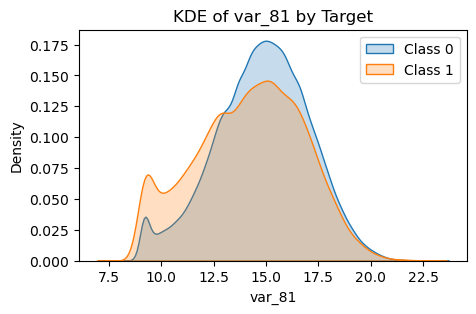

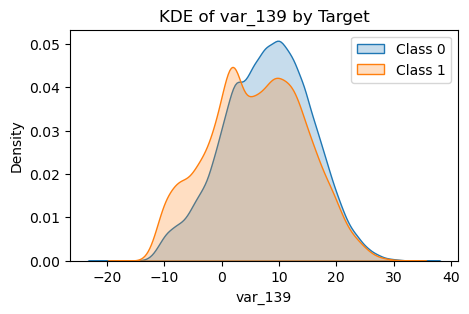

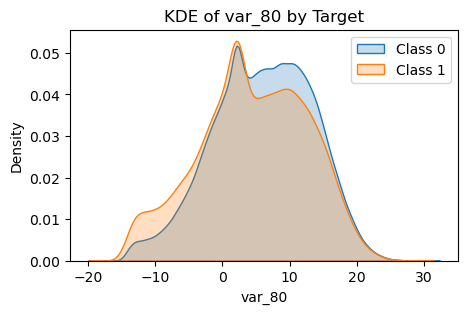

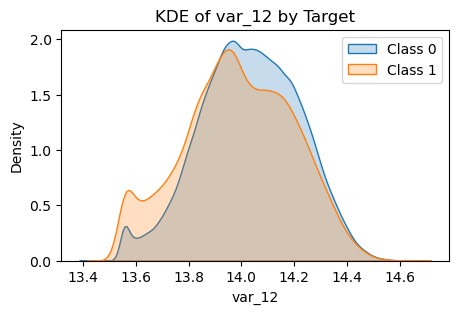

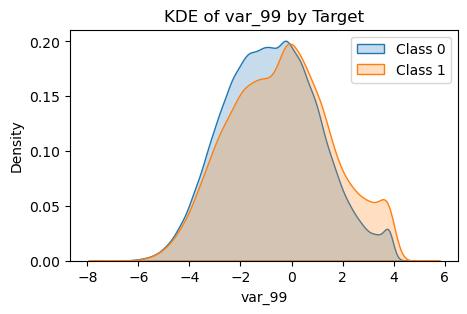

In [77]:
top_5_mi = mi_df.head(5)["feature"].tolist()

print("Top 5 MI features:")
print(top_5_mi)


for col in top_5_mi:

    plt.figure(figsize=(5, 3))

    sns.kdeplot(data=X.loc[y == 0], x=col, label="Class 0", fill=True)

    sns.kdeplot(data=X.loc[y == 1], x=col, label="Class 1", fill=True)

    plt.title(f"KDE of {col} by Target")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

<div dir="rtl">
علت رسم KDE

نمودار KDE برای ۵ Feature برتر بر اساس Mutual Information رسم شد تا توزیع هر Feature در دو کلاس Target با یکدیگر مقایسه شود. هدف اصلی، بررسی میزان جدایی و هم‌پوشانی توزیع کلاس‌های 0 و 1 و شناسایی الگوهای غیرخطی احتمالی است.

گزارش کوتاه

نمودارهای KDE نشان می‌دهند که Featureهای منتخب بر اساس MI تا چه حد می‌توانند بین دو کلاس تمایز ایجاد کنند. هرچه هم‌پوشانی دو توزیع کمتر باشد، Feature قدرت تفکیک بیشتری دارد. همچنین شکل‌های غیرخطی، چندقله‌ای یا وجود Thresholdهای مشخص می‌توانند برای انجام Feature Engineering در مراحل بعدی مفید باشند.

نتیجه: این نمودارها به ما کمک می‌کنند قبل از ساخت Feature جدید، الگوی واقعی رابطه Feature با Target را بررسی کنیم.
<div >

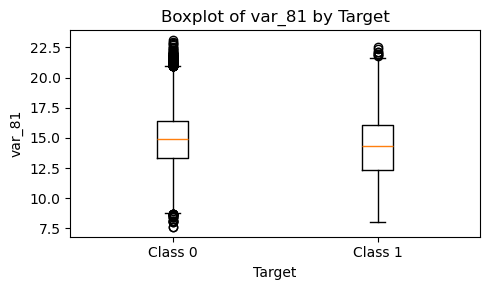

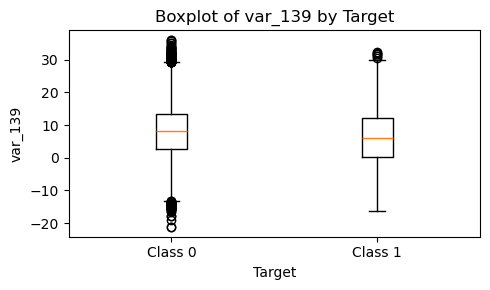

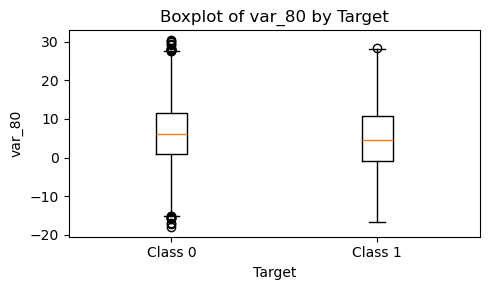

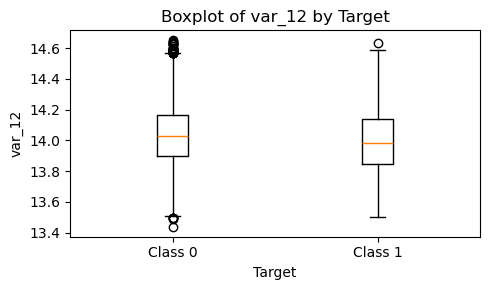

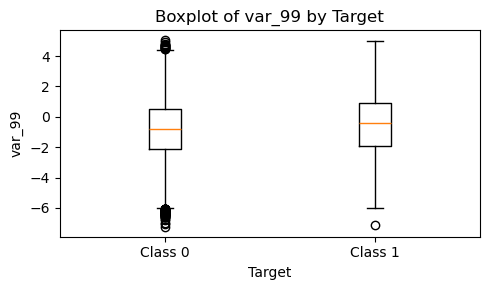

In [79]:
for col in top_5_mi:

    plt.figure(figsize=(5, 3))

    plt.boxplot(
        [
            X.loc[y == 0, col].dropna(),
            X.loc[y == 1, col].dropna()
        ],
        tick_labels=["Class 0", "Class 1"]
    )

    plt.title(f"Boxplot of {col} by Target")
    plt.xlabel("Target")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

<div dir="rtl">
گزارش کوتاه

Boxplot برای مقایسه توزیع ۵ Feature برتر بر اساس Mutual Information بین دو کلاس Target رسم شد. این نمودار امکان بررسی تفاوت میانه، پراکندگی و Outlierها را فراهم می‌کند. اختلاف واضح بین دو کلاس می‌تواند نشان‌دهنده قدرت تفکیک Feature و وجود پتانسیل برای Feature Engineering باشد.

<div>

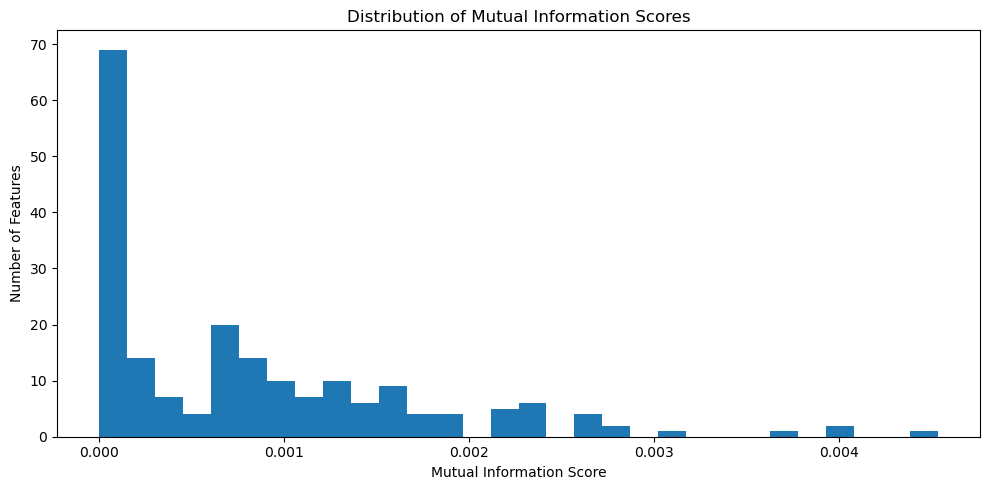

In [104]:
plt.figure(figsize=(10, 5))

plt.hist(mi_df["MI"],bins=30)

plt.xlabel("Mutual Information Score")
plt.ylabel("Number of Features")
plt.title("Distribution of Mutual Information Scores")

plt.tight_layout()
plt.show()

Multivariate

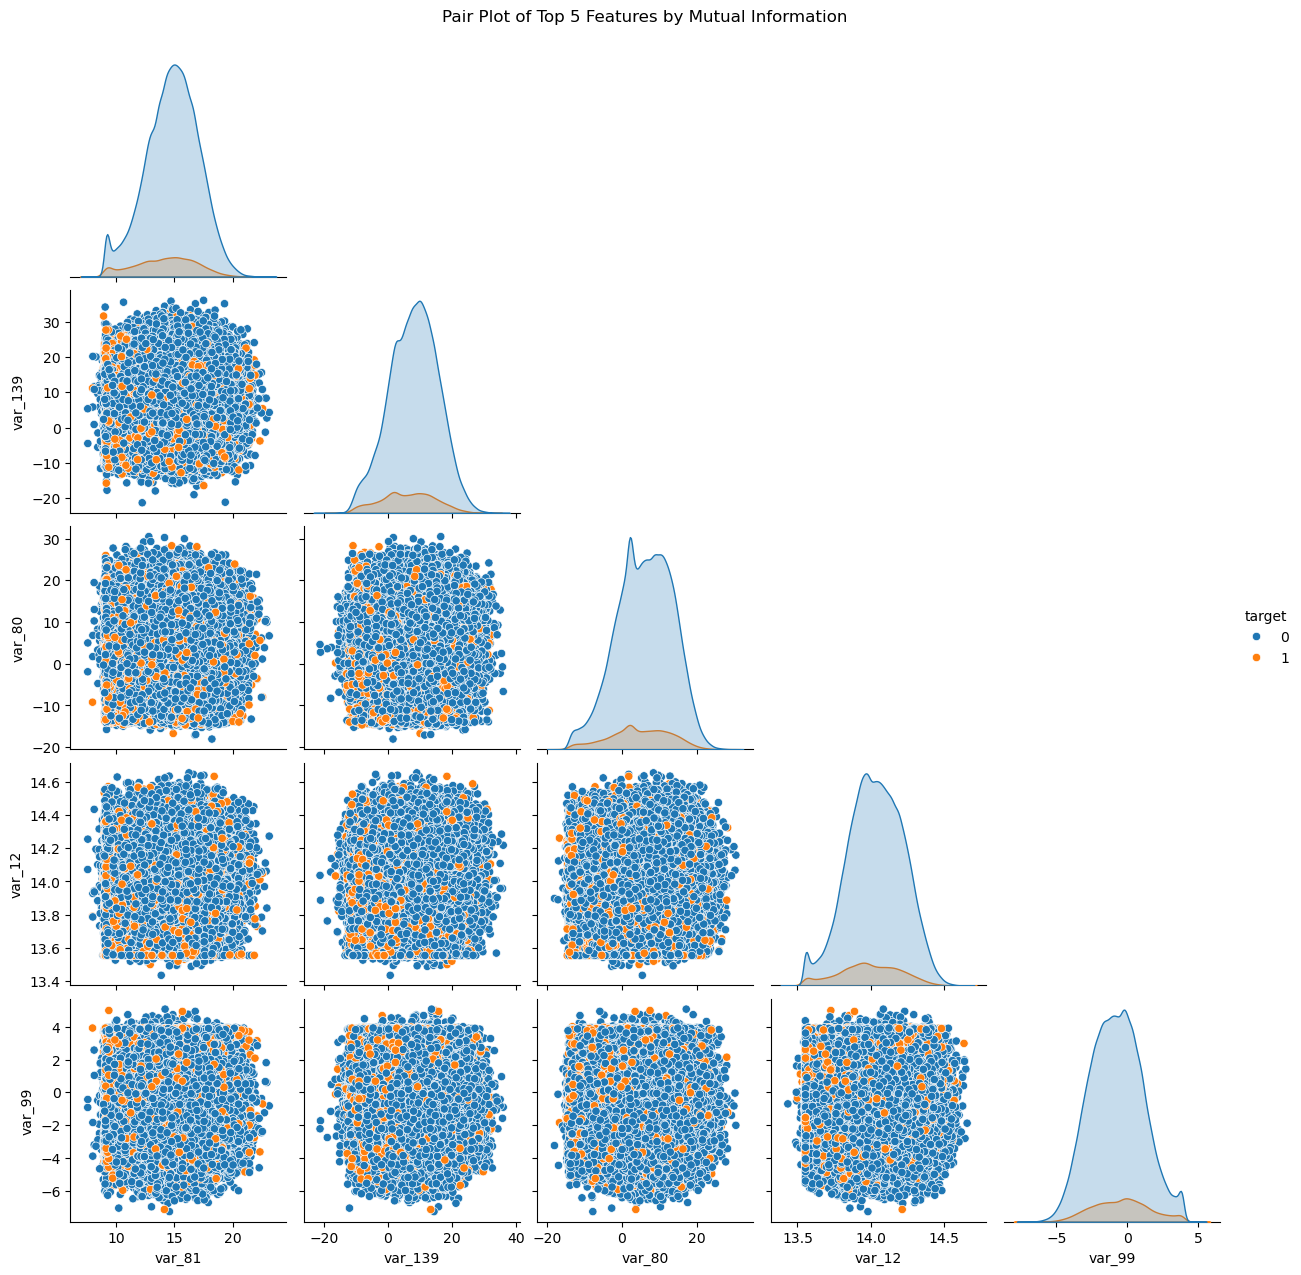

In [80]:
pair_df = X[top_5_mi].copy()
pair_df["target"] = y.values

# Pair Plot
sns.pairplot(pair_df, vars=top_5_mi, hue="target",diag_kind="kde", corner=True)

plt.suptitle("Pair Plot of Top 5 Features by Mutual Information", y=1.02)

plt.show()

<div dir="rtl">
گزارش کوتاه

Pair Plot برای بررسی روابط دوتایی بین ۵ Feature برتر بر اساس Mutual Information رسم شد. هدف، شناسایی همبستگی بین Featureها، میزان جدایی کلاس‌ها و الگوهای احتمالی تعاملی بود. نتایج این نمودار می‌تواند در شناسایی Featureهای تکراری و طراحی Featureهای تعاملی مورد استفاده قرار گیرد.
<div >

#### Multivariate 


### 5. Preprocessing 

In [86]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_valid.shape)
print(y_valid.shape)



(160000, 200)
(40000, 200)
(40000,)


In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

X_valid_scaled

array([[-0.62858622,  2.08121814, -0.53874339, ..., -1.06325184,
         0.57574643, -0.39108186],
       [-1.03211093, -1.68992093,  1.79280274, ...,  0.39091615,
        -1.2159055 ,  0.44398807],
       [-1.59486111, -1.3049001 , -0.96688246, ..., -0.22879349,
         0.92467816,  1.4210405 ],
       ...,
       [-2.0287834 ,  1.36440801, -1.22291196, ..., -2.36205814,
        -0.0133621 ,  0.10635541],
       [-0.60670916,  1.22069523, -0.88704327, ...,  0.63378413,
        -0.30899496, -0.60425693],
       [-0.48469113,  0.19529043,  0.7796423 , ..., -1.8464658 ,
        -0.49116029, -0.02963525]], shape=(40000, 200))

### 6. Feature Selection

#### 6.1 variance & correlation filtering

In [87]:
variance_stats = X.var().sort_values()

print(variance_stats)


var_68       0.000052
var_91       0.023299
var_108      0.029272
var_103      0.034232
var_12       0.036123
              ...    
var_97     159.829825
var_90     172.996399
var_117    176.827823
var_74     199.165216
var_45     458.170238
Length: 200, dtype: float64


In [88]:
variance_stats.describe()

count    200.000000
mean      32.110912
std       48.962477
min        0.000052
25%        2.885795
50%       15.560292
75%       40.330613
max      458.170238
dtype: float64

In [89]:
for threshold in [0, 0.001, 0.01, 0.1, 1]:
    
    count = (variance_stats <= threshold).sum()
    
    print(f"Variance <= {threshold}: {count} features")

Variance <= 0: 0 features
Variance <= 0.001: 1 features
Variance <= 0.01: 1 features
Variance <= 0.1: 10 features
Variance <= 1: 36 features


In [95]:
variance_selector = VarianceThreshold(threshold=0.01)

X_train_var = variance_selector.fit_transform(X_train)
X_valid_var = variance_selector.transform(X_valid)

print(X_train_var.shape)
print(X_valid_var.shape)

(160000, 199)
(40000, 199)


In [96]:
X_train_var = pd.DataFrame(X_train_var, columns=X_train.columns[variance_selector.get_support()])

X_valid_var = pd.DataFrame(X_valid_var, columns=X_train.columns[variance_selector.get_support()])

In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Original features:", X.shape[1])
print("Removed features:", len(to_drop))

Original features: 200
Removed features: 0


In [ ]:
max_corr = upper.max().max()

print("Maximum absolute correlation:", max_corr)

Maximum absolute correlation: 0.009844361358419583


#### The maximum absolute correlation was only 0.009 , below the 0.90 threshold, so no highly redundant feature pairs were identified

### 7. Building Model

#### 7.1 Base line

In [99]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred_lr = lr.predict(X_valid_scaled)


===== logreg =====
Accuracy: 0.7834
precision: 0.2865416436845008
recall : 0.7753731343283582
f1: 0.4184454289166331


In [113]:
y_prob_lr = lr.predict_proba(X_valid_scaled)[:, 1]

accuracy = accuracy_score(y_valid, y_pred_lr)
precision = precision_score(y_valid, y_pred_lr)
recall = recall_score(y_valid, y_pred_lr)
f1 = f1_score(y_valid, y_pred_lr)
roc_auc = roc_auc_score(y_valid, y_prob_lr)
pr_auc = average_precision_score(y_valid, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred_lr))

Accuracy : 0.7834
Precision: 0.2865
Recall   : 0.7754
F1 Score : 0.4184
ROC-AUC  : 0.8599
PR-AUC   : 0.5004

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000


Confusion Matrix:
[[28219  7761]
 [  903  3117]]


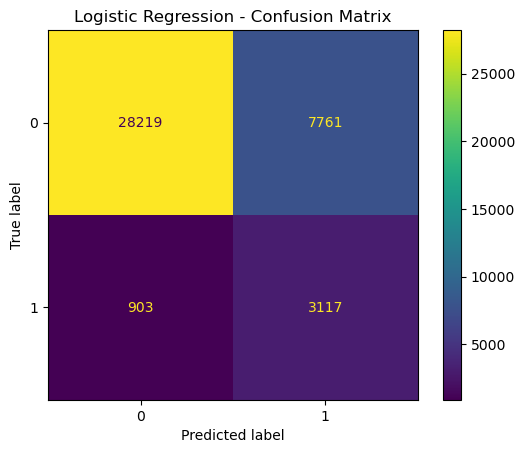

In [114]:
from sklearn.metrics import ConfusionMatrixDisplay
cm =confusion_matrix(y_valid, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()




In [128]:


feature_counts = [150, 100]


selection_models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

}


results = []

selected_features_dict = {}



for model_name, selector_model in selection_models.items():

    print("\n" + "=" * 60)
    print(f"Feature Selection for: {model_name}")
    print("=" * 60)




    selector_model.fit(X_train, y_train)



    importance_df = pd.DataFrame({

        "feature": X_train.columns,

        "importance": selector_model.feature_importances_

    })

    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)


    print( f"Total features: {len(importance_df)}")

    selected_features_dict[model_name] = importance_df


    for n_features in feature_counts:

        print(f"\n{model_name} → Top {n_features} Features")


    
        selected_features = (importance_df.head(n_features)["feature"].tolist())


        X_train_selected = X_train[selected_features]


        X_valid_selected = X_valid[selected_features]


        if model_name == "Random Forest":

            model = RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )

        else: 
        
            model = XGBClassifier(
                n_estimators=300,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )


        model.fit(X_train_selected, y_train)


        y_pred = model.predict(X_valid_selected)

        y_pred = np.asarray(y_pred).ravel()


      
        y_prob = model.predict_proba(X_valid_selected)[:, 1]


        results.append({

            "Model": model_name,

            "n_features": n_features,

            "Accuracy": accuracy_score(
                y_valid,
                y_pred
            ),

            "Precision": precision_score(
                y_valid,
                y_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_valid,
                y_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_valid,
                y_pred,
                zero_division=0
            ),

            "ROC-AUC": roc_auc_score(
                y_valid,
                y_prob
            ),

            "PR-AUC": average_precision_score(
                y_valid,
                y_prob
            )
        })





Feature Selection for: Random Forest
Total features: 200

Random Forest → Top 150 Features

Random Forest → Top 100 Features

Feature Selection for: XGBoost
Total features: 200

XGBoost → Top 150 Features

XGBoost → Top 100 Features


In [129]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)


print("\nFinal Results:")
print(results_df)


Final Results:
           Model  n_features  Accuracy  Precision    Recall        F1  \
0        XGBoost         150  0.914675   0.666667  0.301990  0.415682   
1        XGBoost         100  0.913500   0.656250  0.292537  0.404680   
2  Random Forest         150  0.899500   0.000000  0.000000  0.000000   
3  Random Forest         100  0.899500   0.000000  0.000000  0.000000   

    ROC-AUC    PR-AUC  
0  0.866170  0.518199  
1  0.853558  0.491019  
2  0.826322  0.367133  
3  0.821144  0.363536  


In [130]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR-AUC"],
    ascending=False
).reset_index(drop=True)

results_df

,Model,n_features,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,150,0.914675,0.666667,0.301990,0.415682,0.866170,0.518199
1,XGBoost,100,0.913500,0.656250,0.292537,0.404680,0.853558,0.491019
2,Random Forest,150,0.899500,0.000000,0.000000,0.000000,0.826322,0.367133
3,Random Forest,100,0.899500,0.000000,0.000000,0.000000,0.821144,0.363536


<div dir="rtl">
پس فعلاً XGBoost-150 از نظر ROC-AUC و PR-AUC بهتر است، اما از نظر F1 و مخصوصاً Recall از Logistic Baseline ضعیف‌تر است.

جمع‌بندی

تا این مرحله، XGBoost با 150 Feature بهترین مدل در Feature Selection بوده، اما هنوز مدل نهایی پروژه محسوب نمی‌شود و عملکرد آن باید پس از Hyperparameter Tuning با Baseline مقایسه شود.


<div>